In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Generate Test Output CSV

In [ ]:
# Generate test CSV
CSV_OUT = "/home/admin/julia-dev/data/frogid_captures/data_tables/test_inference_Lit_caerulea_multispecies.csv"

TEST_DIR = "/home/admin/julia-dev/voxaboxen/projects/Lit_caerulea_experiment/Lit_caerulea_bidirectional_2/inference"
LABEL_PATH = "/home/admin/julia-dev/data/frogid_captures/data_tables/fraser_cuecounts_all_data.csv"

rows = []

label_df = pd.read_csv(LABEL_PATH)
for _, row in label_df.iterrows():
    species = row['species']

    if species != 'Litoria caerulea':
        continue

    capture_id = row['id']
    gt_count = row['callcount']
    
    comb_file = os.path.join(TEST_DIR, f'peaks_pred_{capture_id}-comb.txt')
    with open(comb_file, 'r') as fp:
        lines = len(fp.readlines())
    comb_count = lines - 1

    match_file = os.path.join(TEST_DIR, f'peaks_pred_{capture_id}-match.txt')
    with open(match_file, 'r') as fp:
        lines = len(fp.readlines())
    match_count = lines - 1

    rows.append({
        'capture_id': capture_id,
        'comb_count': comb_count,
        'match_count': match_count,
        'gt_count': gt_count
    })

test_df = pd.DataFrame.from_records(rows)
test_df.to_csv(CSV_OUT)

test_df

,capture_id,comb_count,match_count,gt_count
0,8724,1,1,18
1,8746,8,6,19
2,8764,21,19,5
3,8819,18,7,19
4,8951,9,8,11
...,...,...,...,...
520,790540,4,4,3
521,790881,23,8,3
522,791433,6,6,6
523,792782,25,20,25


# Load Test Output for Plotting

In [9]:
CSV_IN = "/home/admin/julia-dev/data/frogid_captures/data_tables/test_inference_Lit_peronii_multispecies.csv"
TITLE = 'Lit_peronii_multispecies'

df = pd.read_csv(CSV_IN, index_col=0)
df

,capture_id,comb_count,match_count,gt_count
0,8724,1,1,18
1,8746,8,6,19
2,8764,21,19,5
3,8819,18,7,19
4,8951,9,8,11
...,...,...,...,...
520,790540,4,4,3
521,790881,23,8,3
522,791433,6,6,6
523,792782,25,20,25


In [10]:
# Add number of species calling
captures_path = "/home/admin/julia-dev/data/frogid_captures/data_tables/FrogID_Captures_2025-03-09T21-01-13+0000.csv"
captures_df = pd.read_csv(captures_path)
capture_id_to_species_map = {x[1]['id']: eval(x[1]['validated_frog_ids']) for x in captures_df.iterrows()}
species_count_col = [len(capture_id_to_species_map[x]) for x in df['capture_id'].values]

df['species_count'] = species_count_col
df

/tmp/ipykernel_3631792/741698940.py:3: DtypeWarning: Columns (32,34,35,39) have mixed types. Specify dtype option on import or set low_memory=False.
  captures_df = pd.read_csv(captures_path)


,capture_id,comb_count,match_count,gt_count,species_count
0,8724,1,1,18,1
1,8746,8,6,19,3
2,8764,21,19,5,1
3,8819,18,7,19,3
4,8951,9,8,11,1
...,...,...,...,...,...
520,790540,4,4,3,0
521,790881,23,8,3,0
522,791433,6,6,6,2
523,792782,25,20,25,2


# V1 Plots

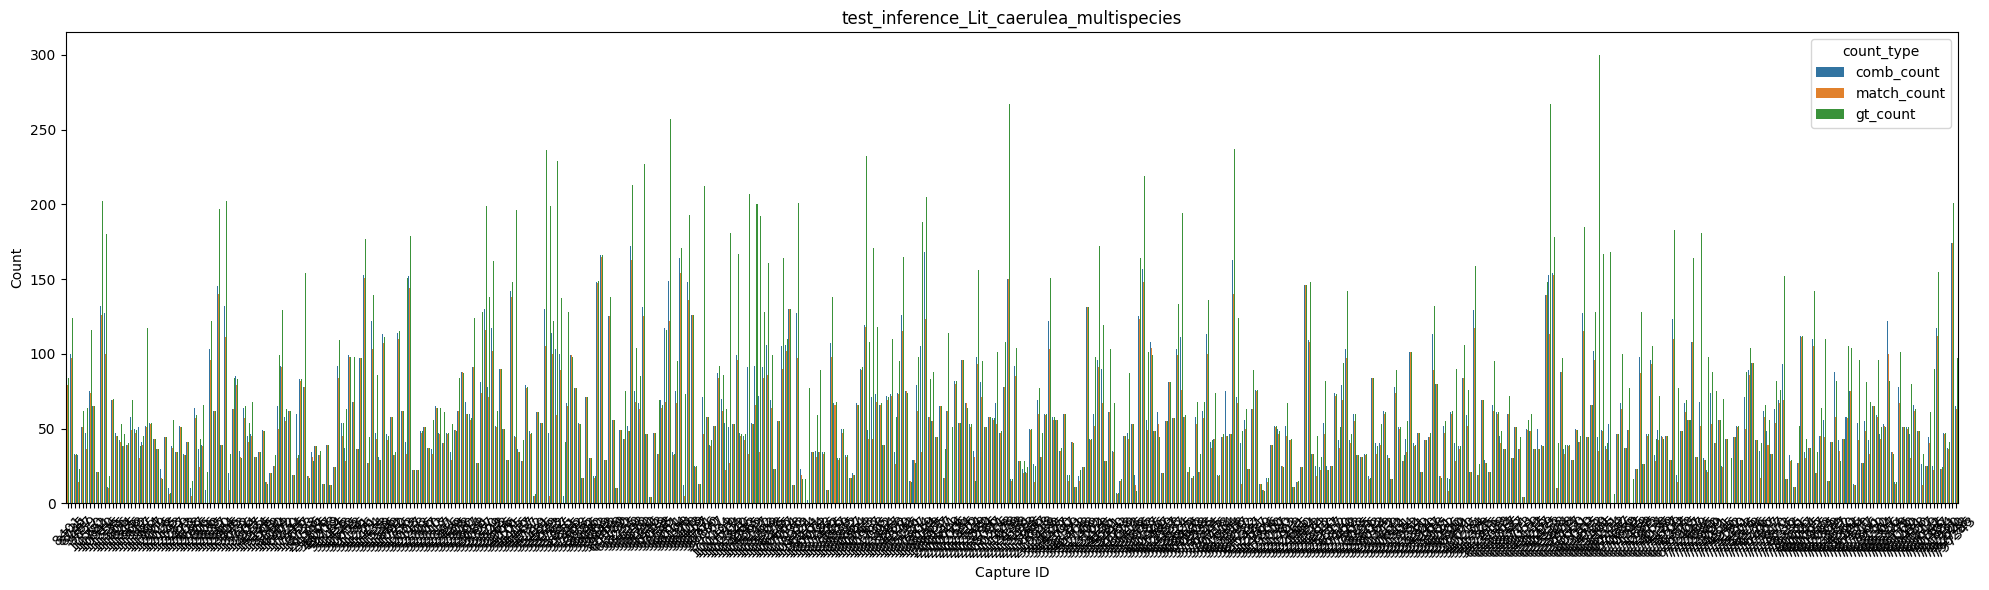

In [8]:
# Convert from wide → long format
df_long = df.melt(
    id_vars="capture_id",
    value_vars=["comb_count", "match_count", "gt_count"],
    var_name="count_type",
    value_name="count"
)

# Plot grouped bar chart
plt.figure(figsize=(20, 6))
sns.barplot(
    data=df_long,
    x="capture_id",
    y="count",
    hue="count_type"
)

plt.title(PLOT_TITLE)
plt.xlabel("Capture ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.show()

plt.savefig('count_comparison_plot.png', dpi=300)

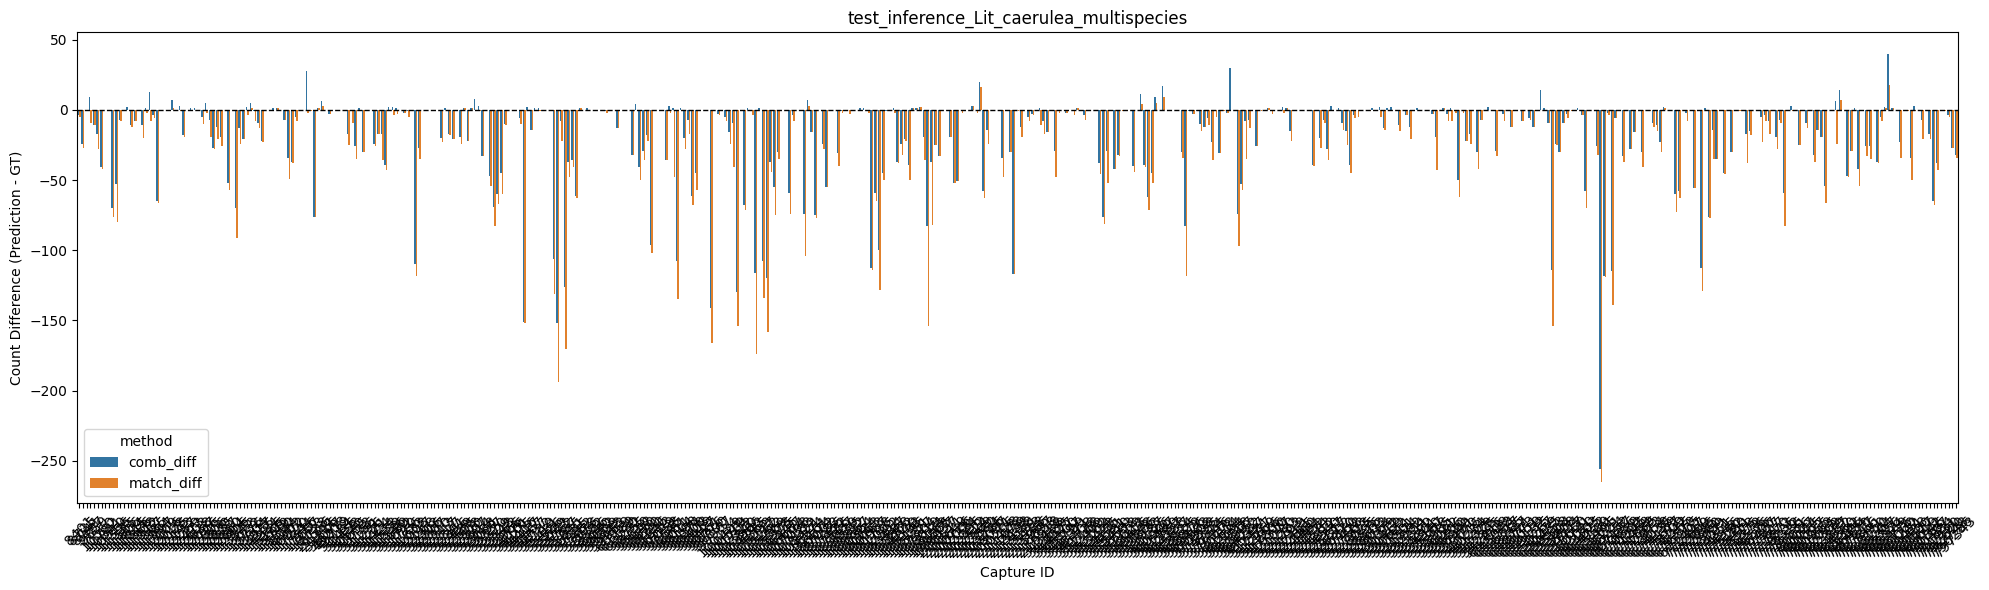

In [9]:
# Compute differences from ground truth
df["comb_diff"] = df["comb_count"] - df["gt_count"]
df["match_diff"] = df["match_count"] - df["gt_count"]

# Convert to long format
df_diff_long = df.melt(
    id_vars="capture_id",
    value_vars=["comb_diff", "match_diff"],
    var_name="method",
    value_name="diff_from_gt"
)

# Plot difference bars
plt.figure(figsize=(20, 6))
sns.barplot(
    data=df_diff_long,
    x="capture_id",
    y="diff_from_gt",
    hue="method"
)

# Add baseline at zero
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.title(PLOT_TITLE)
plt.xlabel("Capture ID")
plt.ylabel("Count Difference (Prediction - GT)")
plt.xticks(rotation=45)
plt.tight_layout()
# plt.show()

plt.savefig('count_diff_plot.png', dpi=300)

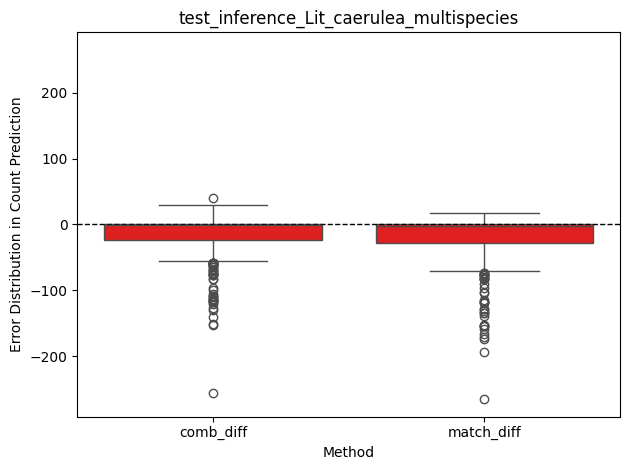

In [10]:
sns.boxplot(
    data=df_diff_long,
    x="method",
    y="diff_from_gt",
    color="red"
)
plt.axhline(0, linestyle="--", color="black", linewidth=1)

# Force symmetric limits around zero
max_abs = np.abs(df_diff_long["diff_from_gt"]).max()
plt.ylim(-max_abs * 1.1, max_abs * 1.1)

plt.title(PLOT_TITLE)
plt.xlabel("Method")
plt.ylabel("Error Distribution in Count Prediction")
plt.tight_layout()
# plt.show()

plt.savefig('error_dist_plot.png', dpi=300)

# V2 Plots

In [11]:
df = df[df['species_count'] > 0]

y_true = df['gt_count'].values
y_pred = df['match_count'].values

n_species_calling = df['species_count'].values

=== Metrics ===
MAE:       3.757
RMSE:      6.203
Bias:      -0.696
R^2:       0.286
Within ±1: 45.9%
Within ±2: 55.9%
Within ±5: 75.9%


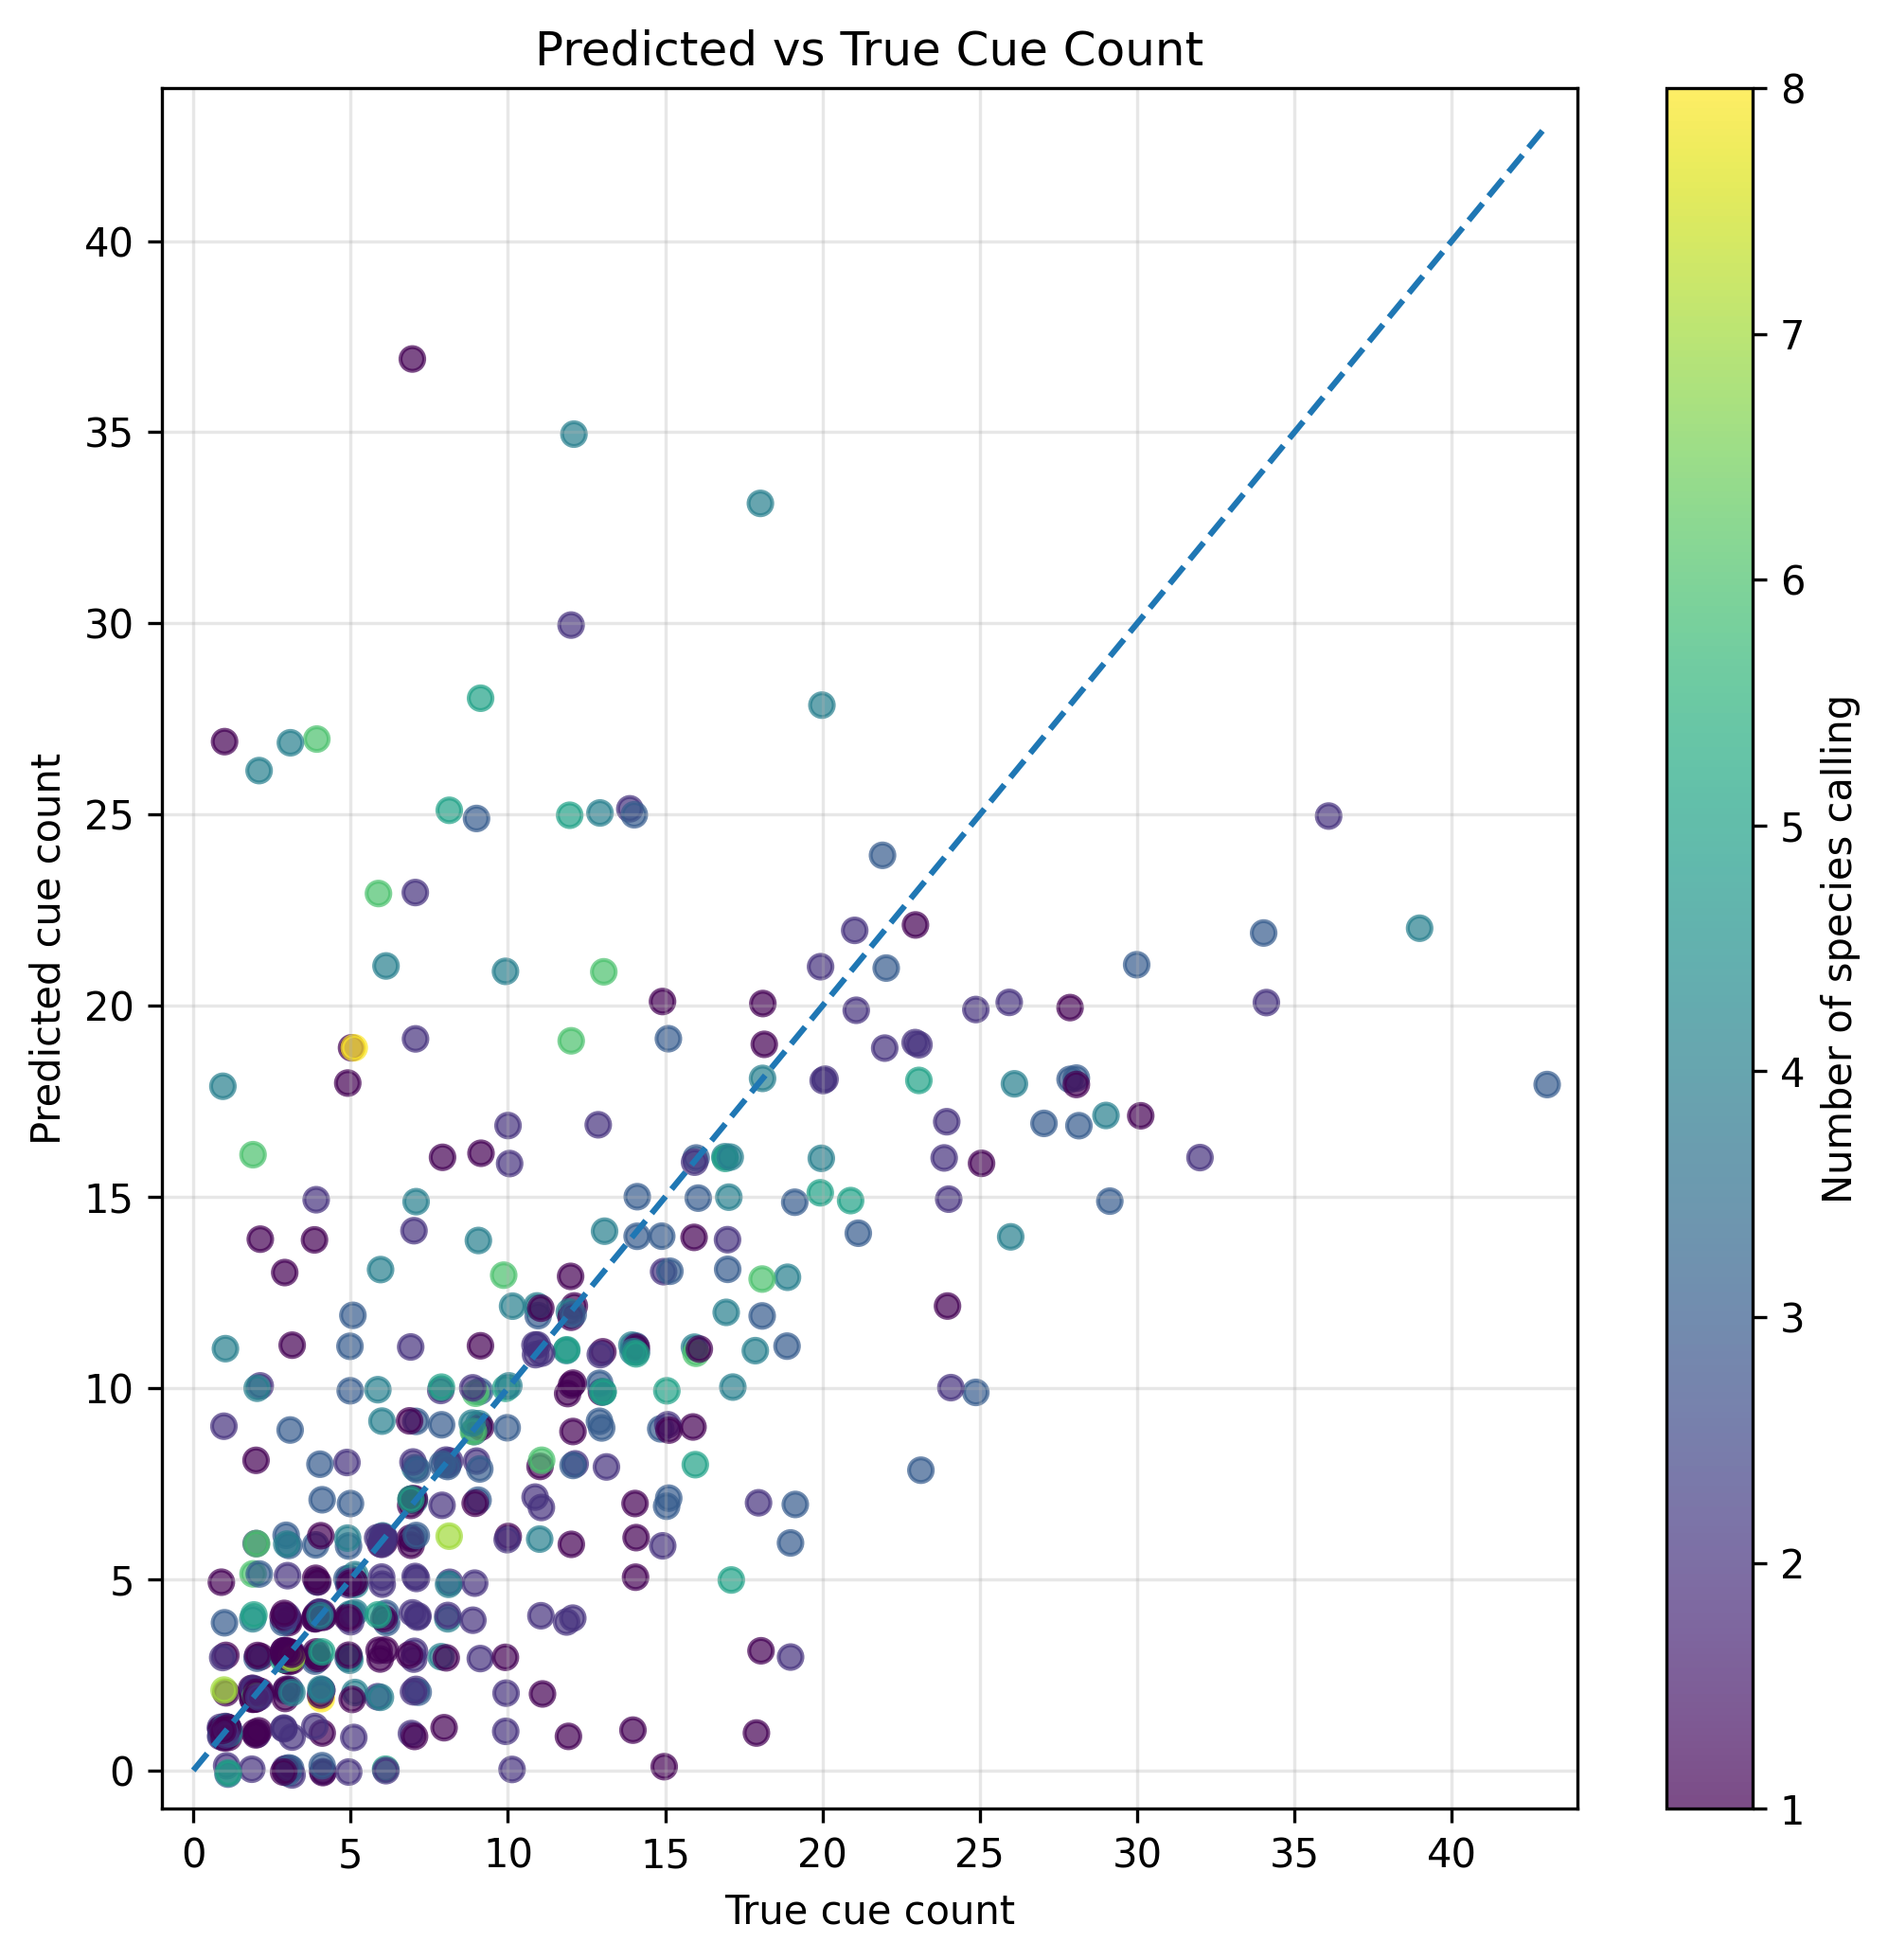

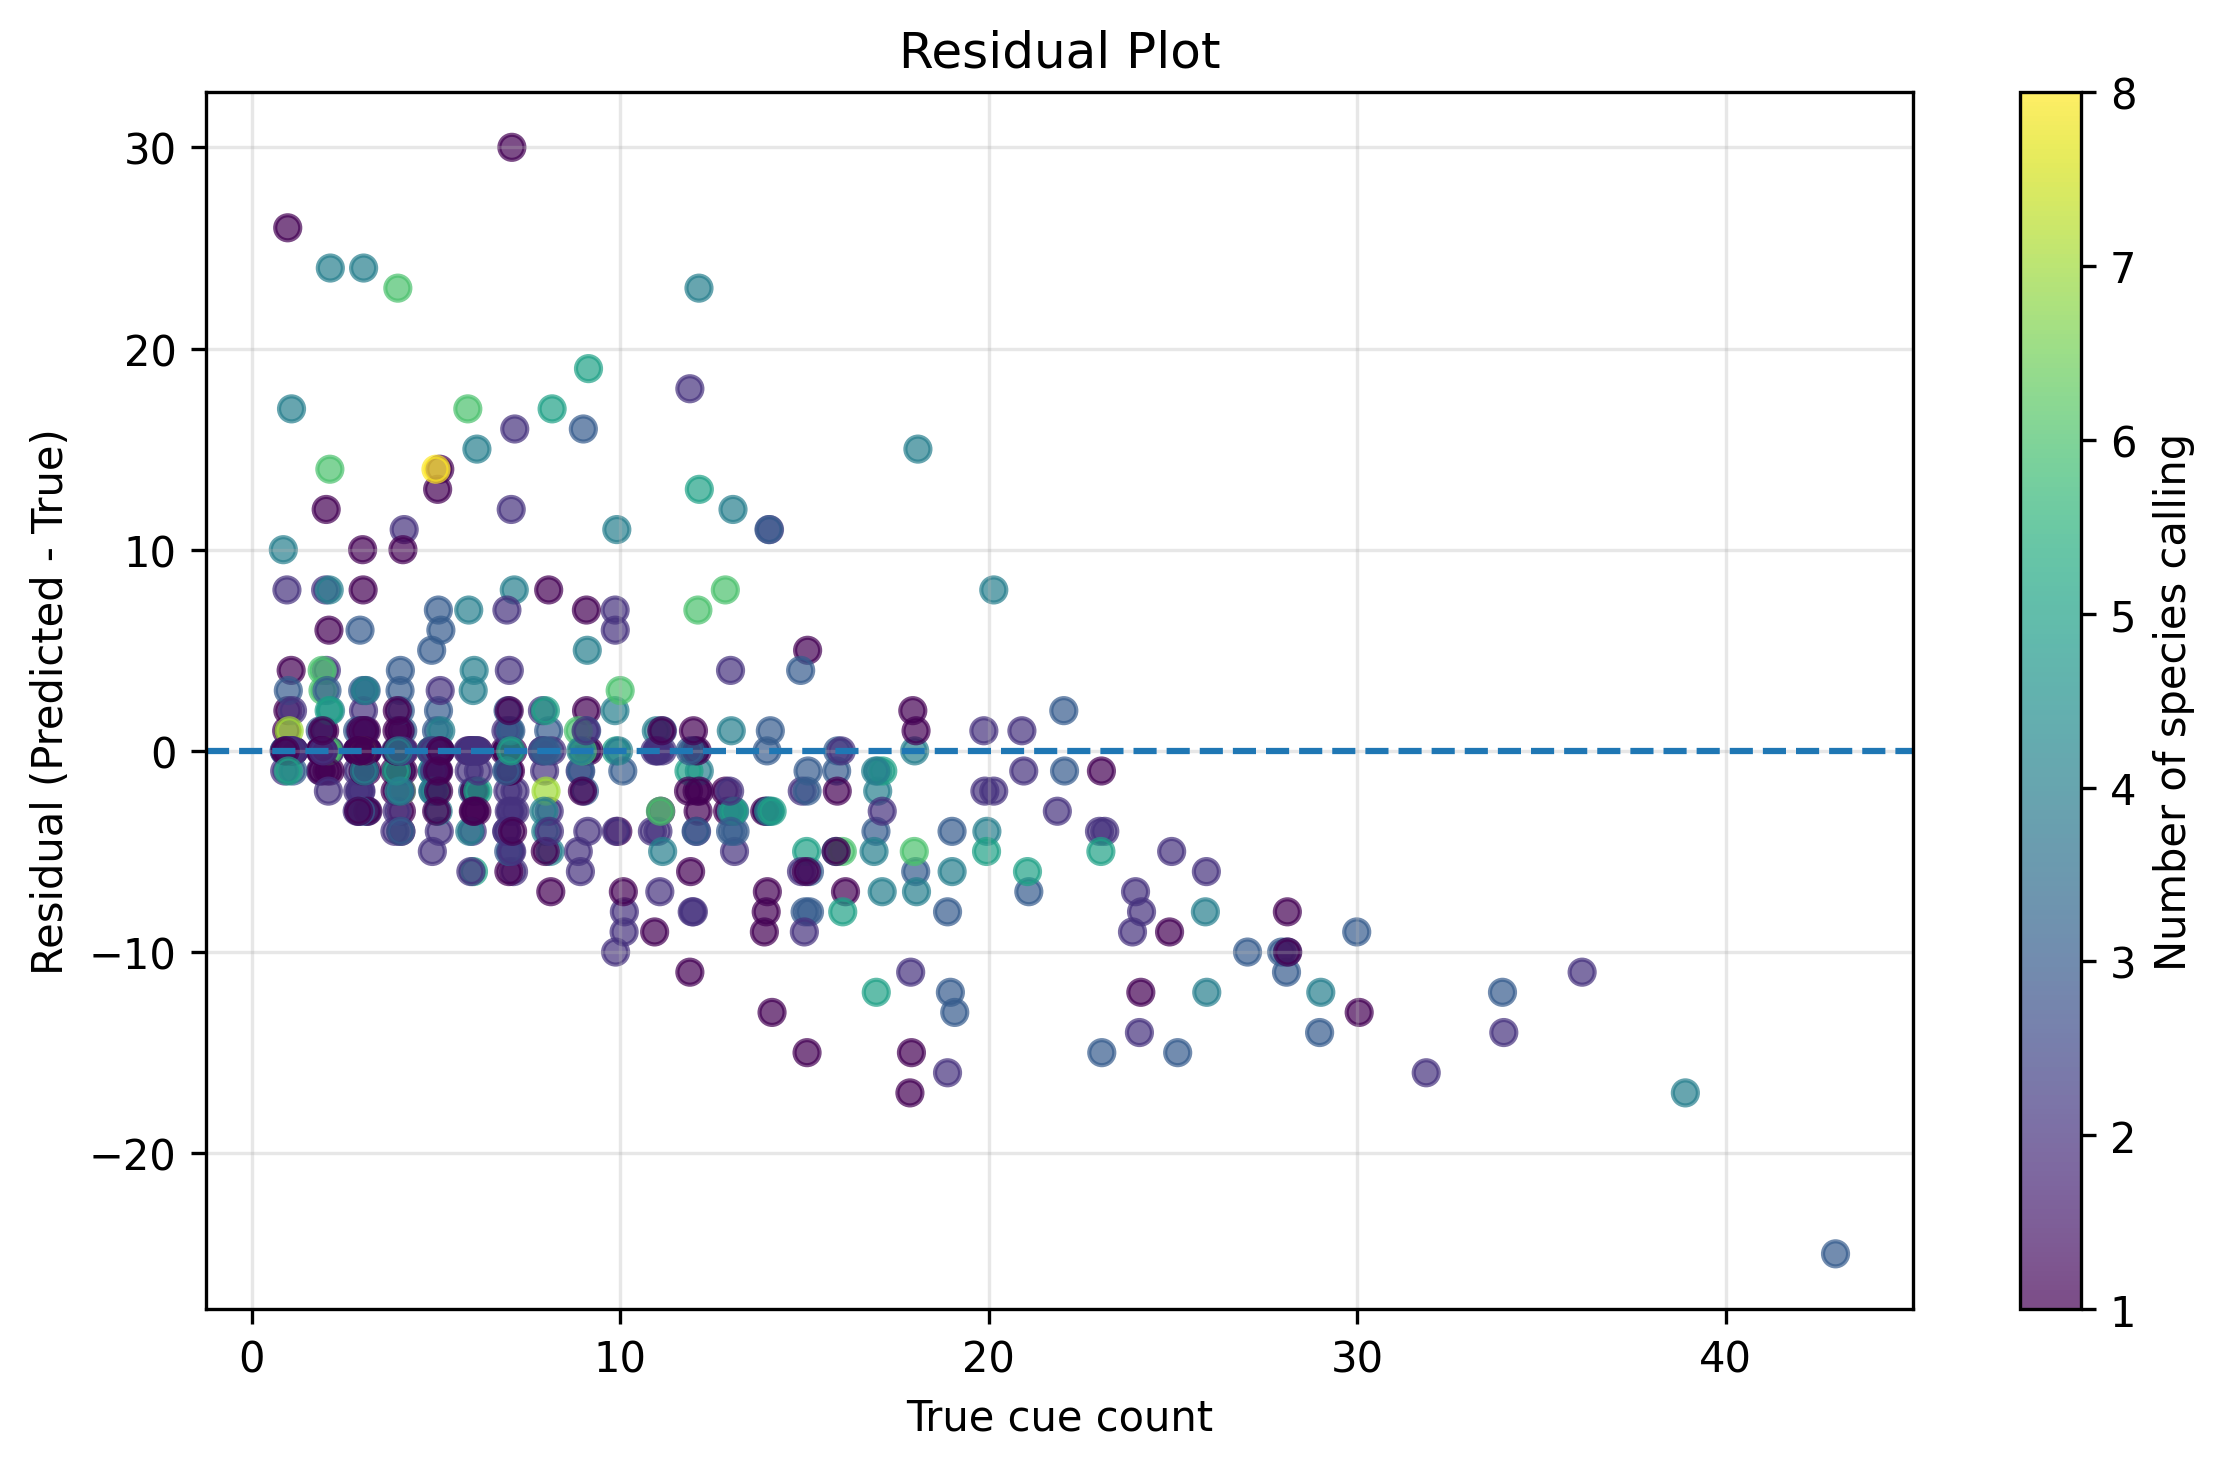

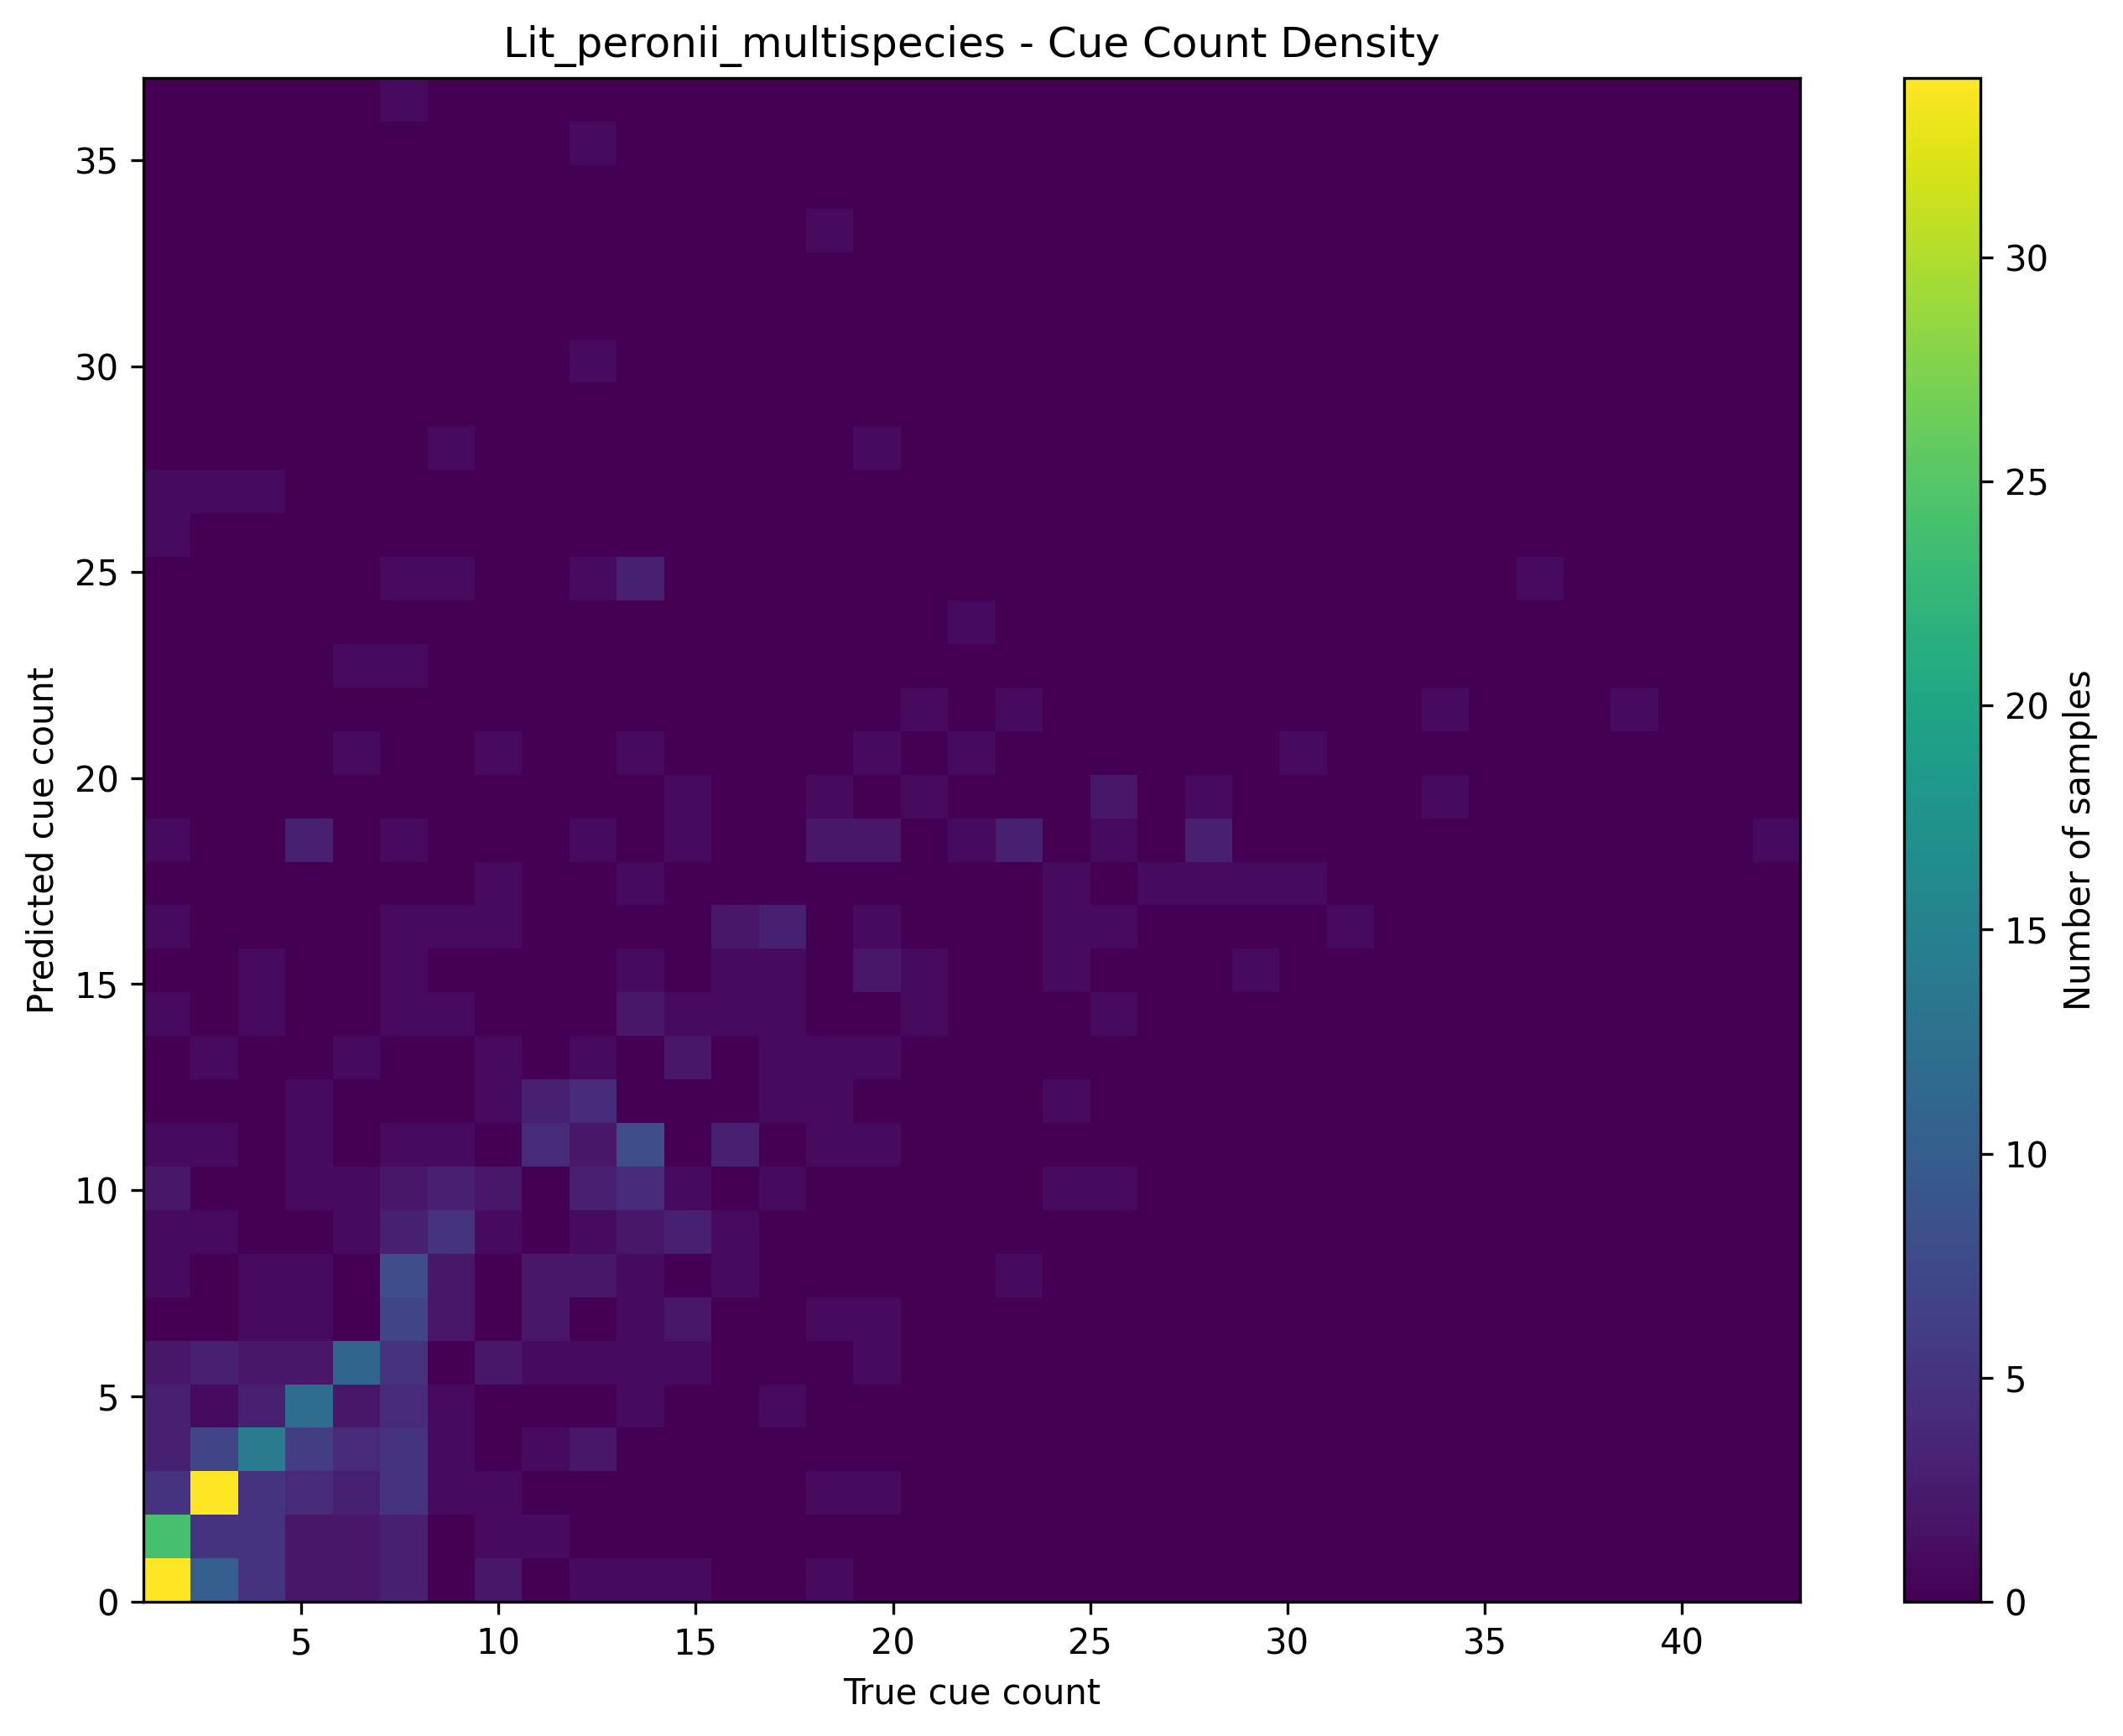

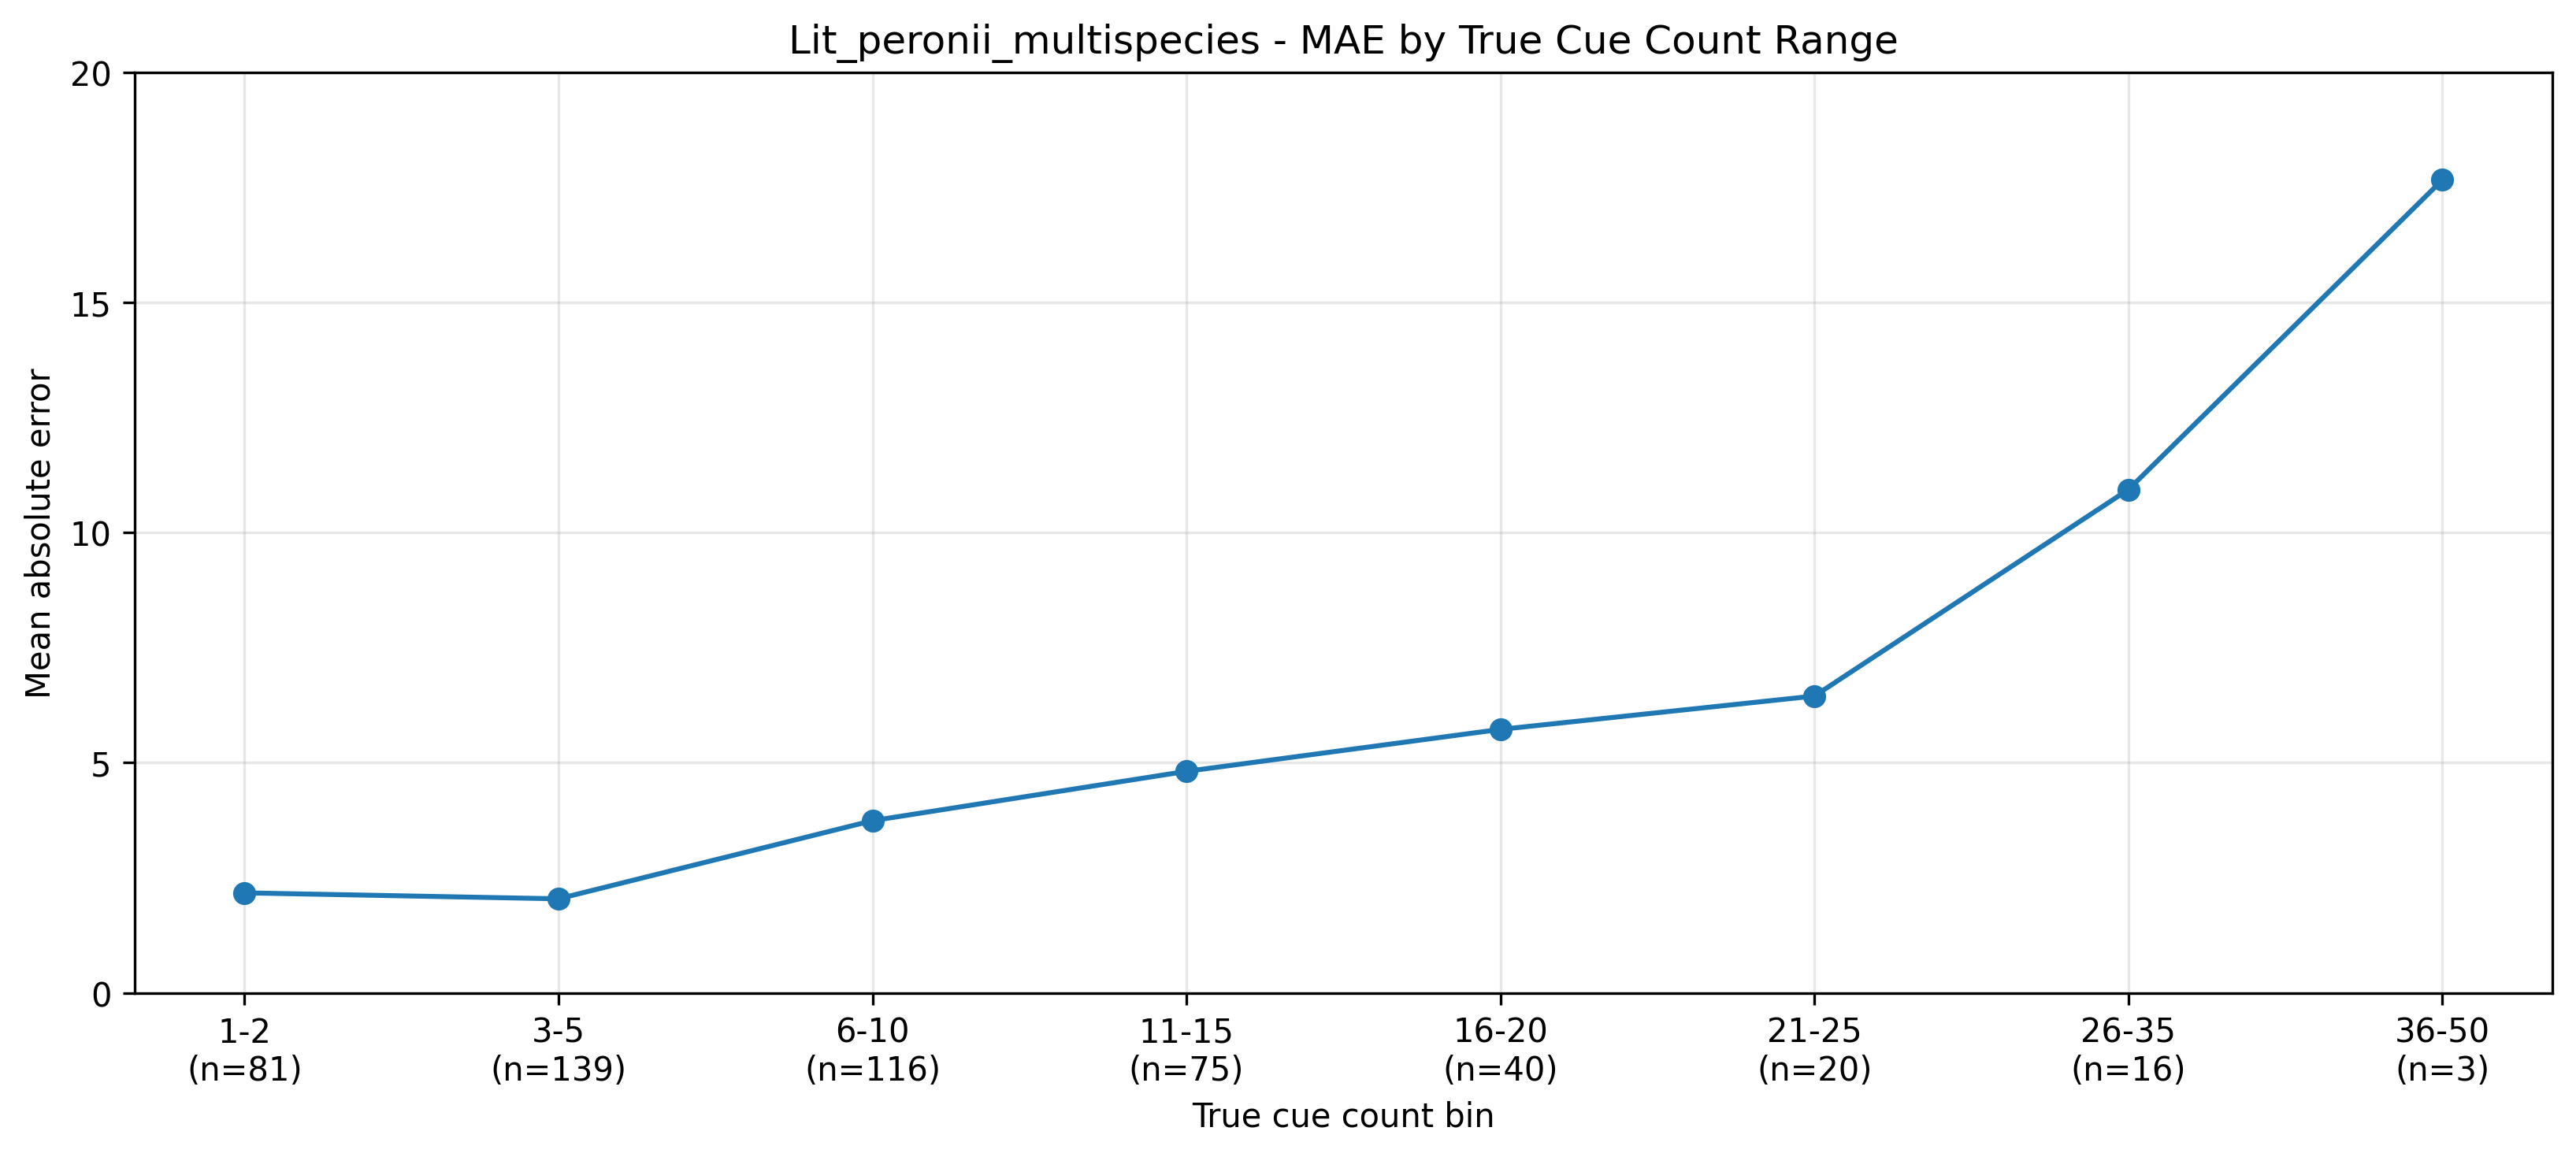

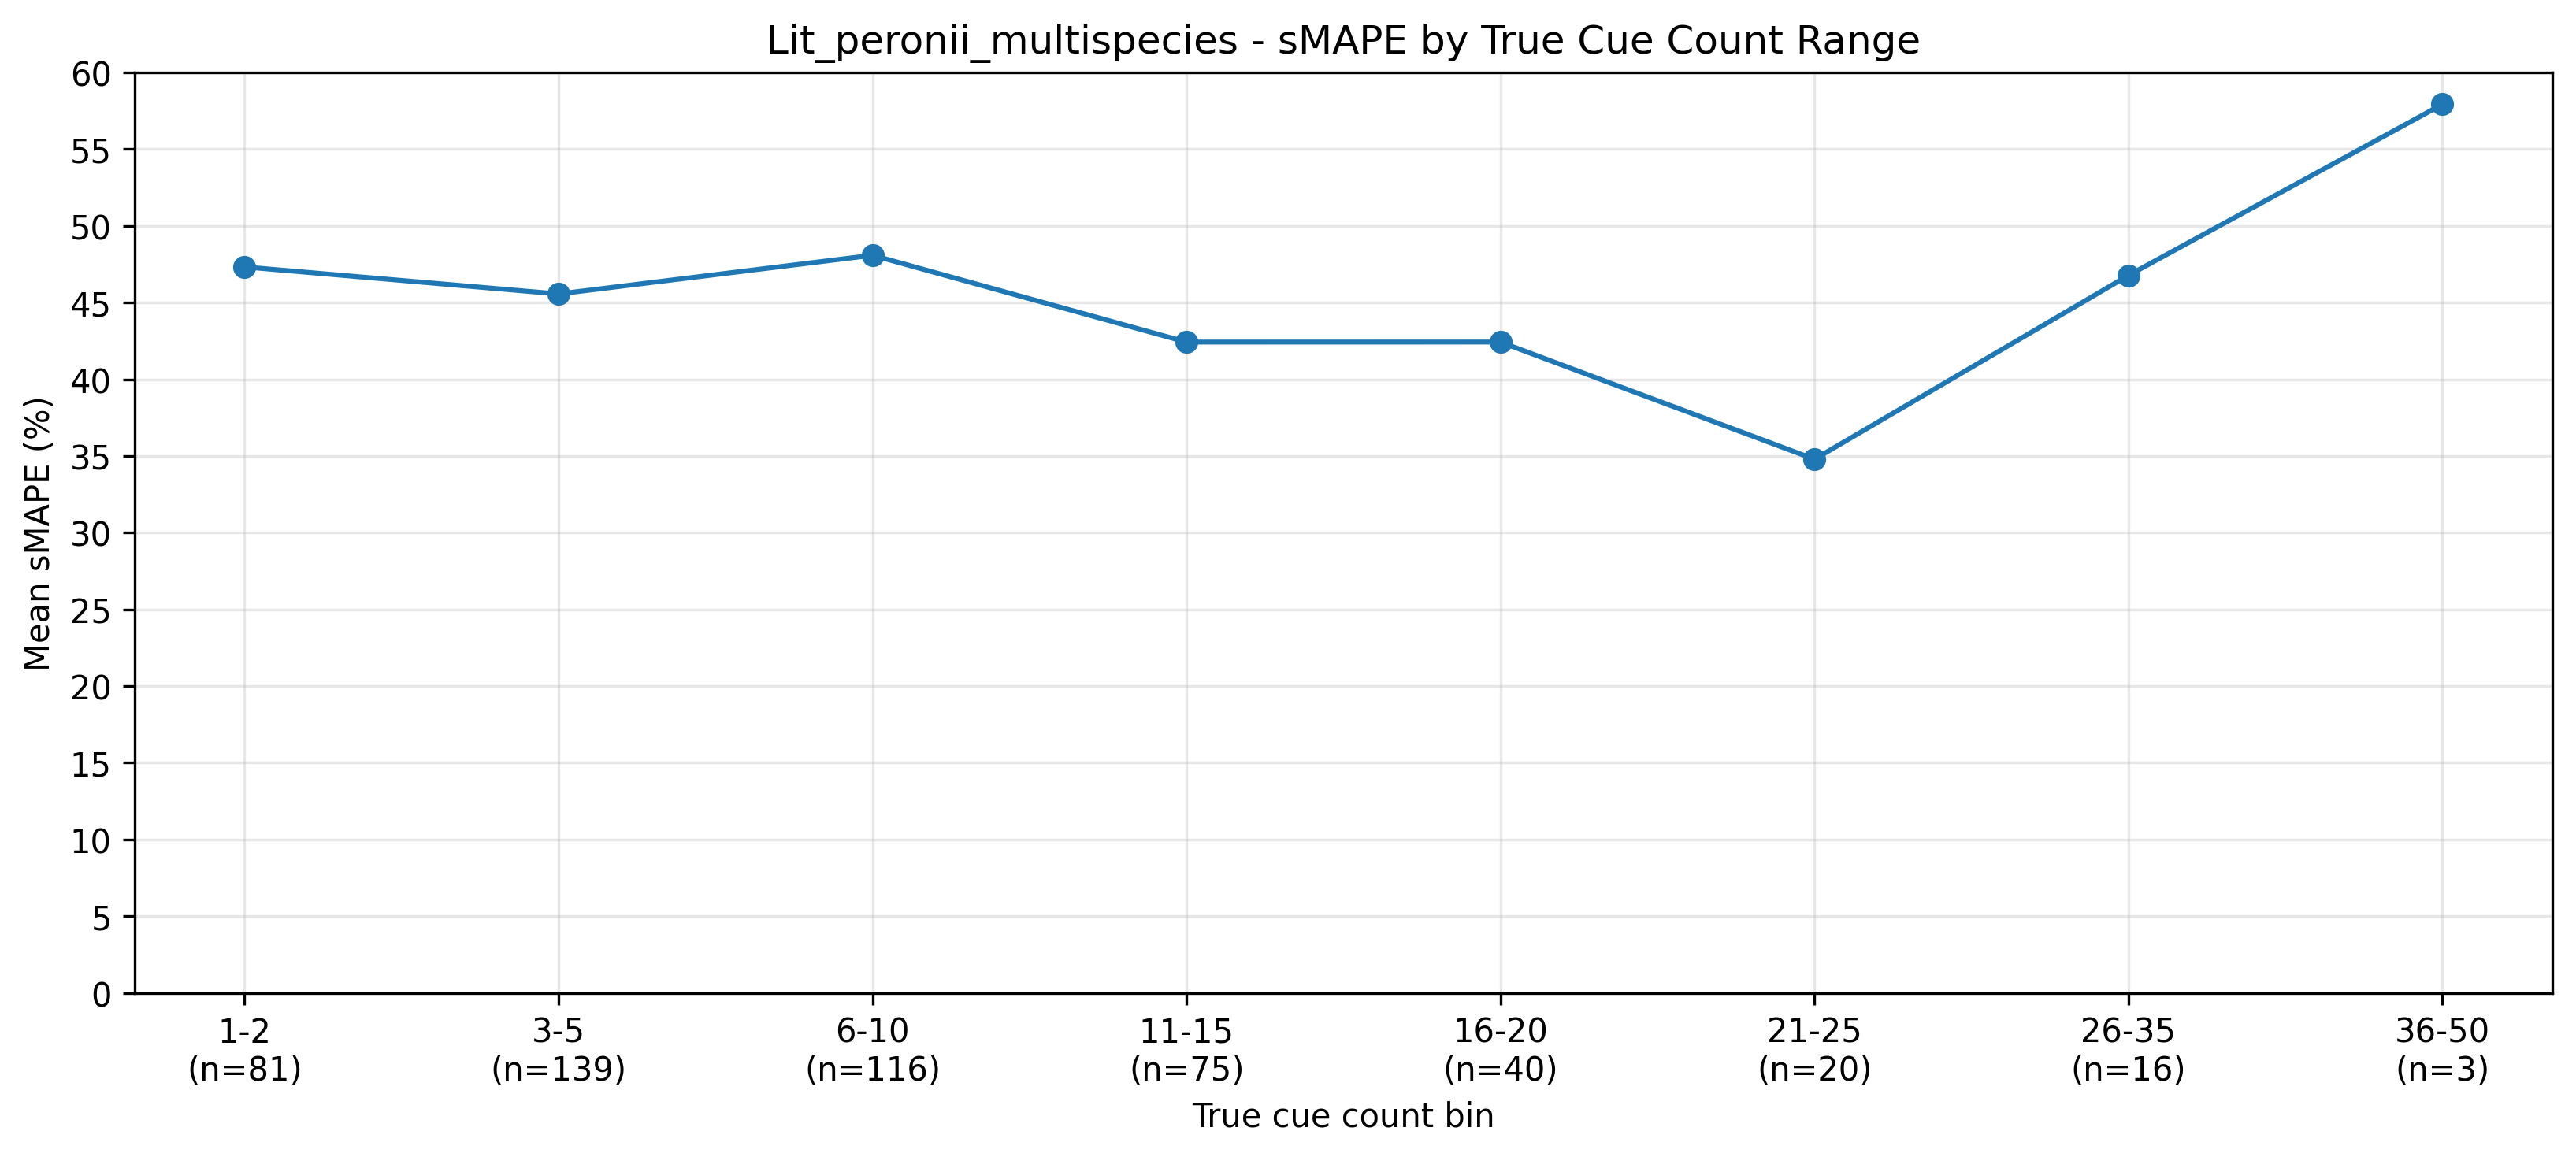

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# INPUTS
# ============================================================

# Optional if your model outputs continuous values
y_pred_rounded = np.clip(np.round(y_pred).astype(int), 0, None)

# ============================================================
# METRICS
# ============================================================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
bias = np.mean(y_pred - y_true)
r2 = r2_score(y_true, y_pred)

abs_error = np.abs(y_pred - y_true)
within_1 = np.mean(abs_error <= 1) * 100
within_2 = np.mean(abs_error <= 2) * 100
within_5 = np.mean(abs_error <= 5) * 100

print("=== Metrics ===")
print(f"MAE:       {mae:.3f}")
print(f"RMSE:      {rmse:.3f}")
print(f"Bias:      {bias:.3f}")
print(f"R^2:       {r2:.3f}")
print(f"Within ±1: {within_1:.1f}%")
print(f"Within ±2: {within_2:.1f}%")
print(f"Within ±5: {within_5:.1f}%")

# ============================================================
# HELPER SETTINGS
# ============================================================
jitter_strength = 0.15
min_val = min(np.min(y_true), np.min(y_pred))
max_val = max(np.max(y_true), np.max(y_pred))

# ============================================================
# PLOT 1: TRUE VS PREDICTED SCATTER
# ============================================================
plt.figure(figsize=(7, 7), dpi=300)

sc = plt.scatter(
    y_true + np.random.uniform(-jitter_strength, jitter_strength, size=len(y_true)),
    y_pred + np.random.uniform(-jitter_strength, jitter_strength, size=len(y_pred)),
    c=n_species_calling,
    alpha=0.7
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.xlabel("True cue count")
plt.ylabel("Predicted cue count")
plt.title("Predicted vs True Cue Count")
plt.xlim(min_val - 1, max_val + 1)
plt.ylim(min_val - 1, max_val + 1)
plt.grid(True, alpha=0.3)
plt.colorbar(sc, label="Number of species calling")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: RESIDUAL PLOT
# ============================================================
residuals = y_pred - y_true

plt.figure(figsize=(8, 5), dpi=300)
sc = plt.scatter(
    y_true + np.random.uniform(-jitter_strength, jitter_strength, size=len(y_true)),
    residuals,
    c=n_species_calling,
    alpha=0.7
)

plt.axhline(0, linestyle='--')
plt.xlabel("True cue count")
plt.ylabel("Residual (Predicted - True)")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)
plt.colorbar(sc, label="Number of species calling")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: 2D HISTOGRAM / DENSITY
# ============================================================
plt.figure(figsize=(9, 7), dpi=300)
hist = plt.hist2d(y_true, y_pred, bins=35)
plt.colorbar(label="Number of samples")
plt.xlabel("True cue count")
plt.ylabel("Predicted cue count")
plt.title(f"{TITLE} - Cue Count Density")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 4: MAE BY TRUE COUNT BIN
# ============================================================
bins = [-0.1, 0, 2, 5, 10, 15, 20, 25, 35, 50, 75, 100, 150, 200, 300, np.inf]
labels = ["0", "1-2", "3-5", "6-10", "11-15", "16-20", "21-25", "26-35",
          "36-50", "51-75", "76-100", "101-150", "151-200", "201-300", "300+"]

df_plot = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})
df_plot["abs_error"] = np.abs(df_plot["pred"] - df_plot["true"])

df_plot["true_bin"] = pd.cut(
    df_plot["true"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

mae_by_bin = df_plot.groupby("true_bin", observed=True)["abs_error"].mean()
n_by_bin = df_plot.groupby("true_bin", observed=True).size()

x_labels = [f"{label}\n(n={n})" for label, n in zip(mae_by_bin.index.astype(str), n_by_bin.values)]

plt.figure(figsize=(11, 5), dpi=300)
plt.plot(range(len(mae_by_bin)), mae_by_bin.values, marker='o')
plt.xlabel("True cue count bin")
plt.ylabel("Mean absolute error")
plt.title(f"{TITLE} - MAE by True Cue Count Range")
plt.grid(True, alpha=0.3)
plt.xticks(range(len(mae_by_bin)), x_labels)
plt.yticks(np.arange(0, np.ceil(np.nanmax(mae_by_bin.values)) + 5, 5))
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 5: sMAPE BY TRUE COUNT BIN
# ============================================================
df_smape = pd.DataFrame({
    "true": y_true,
    "pred": y_pred
})

df_smape["true_bin"] = pd.cut(
    df_smape["true"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

denom = (np.abs(df_smape["true"]) + np.abs(df_smape["pred"])) / 2
df_smape["smape"] = np.where(
    denom == 0,
    0,
    np.abs(df_smape["pred"] - df_smape["true"]) / denom * 100
)

smape_by_bin = df_smape.groupby("true_bin", observed=True)["smape"].mean()
n_smape_by_bin = df_smape.groupby("true_bin", observed=True).size()

x_labels = [f"{label}\n(n={n})" for label, n in zip(smape_by_bin.index.astype(str), n_smape_by_bin.values)]

plt.figure(figsize=(11, 5), dpi=300)
plt.plot(range(len(smape_by_bin)), smape_by_bin.values, marker='o')
plt.xlabel("True cue count bin")
plt.ylabel("Mean sMAPE (%)")
plt.title(f"{TITLE} - sMAPE by True Cue Count Range")
plt.grid(True, alpha=0.3)
plt.xticks(range(len(smape_by_bin)), x_labels)
plt.yticks(np.arange(0, np.ceil(np.nanmax(smape_by_bin.values)) + 5, 5))
plt.tight_layout()
plt.show()